# What Does It Mean for Synthetic Data to Be Indistinguishable?

This notebook is the **generation + evaluation pipeline** for the paper.
It trains generators, computes metrics, and builds a small number of paper-ready figures.

---

## Research framing

**Central question:** When we say synthetic data is "indistinguishable" from real
data, what do we actually mean — and does the answer depend on how we measure it?

**Why this matters:** For expensive-to-collect datasets like HIV vaccine response
data, synthetic augmentation is attractive — but only if the synthetic data is
faithful enough to be useful without leaking private information.

**Why one metric is not enough:**

| Lens | Question | Metric |
|------|----------|--------|
| **Marginal** | Do individual feature distributions match? | KLD per feature |
| **Structural** | Are pairwise correlations preserved? | Correlation diff |
| **Functional** | Can a classifier tell them apart? | RF Separation |
| **Utility** | Is a model trained on synthetic data useful? | TSTR F1 |

A generator can score well on one lens and fail on another. This notebook
measures all four, across three generators (Bootstrap, GMM, CVAE) and three
datasets (HIV, breast cancer, diabetes).

---

### Structure

1. **Setup** — imports, paths, config
2. **Data** — load and summarise datasets
3. **Experiment runner** — one function, all experiments
4. **Run experiments** — four blocks (full, forward, reverse, drop-one)
5. **Paper figures** — small number of targeted, titled figures
6. **Save** — CSV + pickle for downstream analysis notebooks

---
## 1. Setup

In [1]:
%matplotlib inline

import sys
import warnings
import pickle
from pathlib import Path

ROOT = Path().resolve().parents[0]
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings('ignore', category=DataConversionWarning)

from loaders import load_breast, load_diabetes, load_HIV
from models.cvae import train_cvae_on_arrays, sample_cvae_dataset
from models.bootstrap import sample_bootstrap
from models.gmm import sample_gmm
from models.iid_columnwise import sample_columnwise
from metrics import evaluate_all, stratified_subsample, print_dataset_summary
from tables import make_table_full, save_all_tables
from plots import (
    METHOD_COLORS, METHOD_ORDER,
    plot_corr_matrices, plot_pca_projection,
    plot_kld_per_feature_by_method,
    paper_fig_rf_sep_vs_frac, paper_fig_kld_vs_rf_sep, paper_fig_ablation,
)

# ── Reproducibility & paths ──
SEED    = 42
OUTDIR  = Path('../results')
FIGDIR  = OUTDIR / 'figures'
OUTDIR.mkdir(parents=True, exist_ok=True)
FIGDIR.mkdir(parents=True, exist_ok=True)

# ── Experiment grid ──
DATASETS   = [load_HIV, load_breast, load_diabetes]
METHODS    = ['bootstrap', 'gmm', 'cvae', 'iid_columnwise']
FRACTIONS  = [0.2, 0.3, 0.4, 0.5, 0.75, 1.0]
ABLATION_FRAC = 1.0
FORWARD_KS = [3, 5, 10, 15, 20]
REVERSE_KS = [1, 3, 5, 10]
CVAE_EPOCHS = 200

print(f'Output: {OUTDIR.resolve()}')
print(f'Figures: {FIGDIR.resolve()}')

Output: C:\Users\tonyt\Desktop\synthetic-data\results
Figures: C:\Users\tonyt\Desktop\synthetic-data\results\figures


---
## 2. Datasets

| Dataset | Domain | Why included |
|---------|--------|--------------|
| **HIV** | Vaccine response (clinical) | Primary application dataset — expensive to collect, high p |
| **Breast cancer** | Diagnostic (clinical) | Secondary sanity check — well-studied, moderate p |
| **Diabetes** | Metabolic (clinical) | Tertiary — low p, tests whether methods differ on simple data |

In [2]:
print_dataset_summary(DATASETS)

Dataset                  p    Class 0    Class 1    Total
--------------------------------------------------------
HIV                     63         23         68       91
breast_cancer           30        212        357      569
diabetes                 8        500        268      768


---
## 3. Experiment runner

One function handles all experiment types. It:
- Subsamples real data
- Selects features (full / forward / reverse / drop-one)
- Trains each generator
- Computes metrics (no figures — those are built separately in Section 5)
- Returns tidy rows + raw arrays for later plotting

In [3]:
def fraction_to_n(y, frac):
    """Convert a class fraction to (n0, n1), minimum 2 per class."""
    n0 = max(2, int(np.floor((y == 0).sum() * frac)))
    n1 = max(2, int(np.floor((y == 1).sum() * frac)))
    return n0, n1


def select_feature_subset(X, feature_names, mode='full',
                          ranked_idx=None, k=None, drop_idx=None):
    p = X.shape[1]
    if mode == 'full':     return np.arange(p)
    if mode == 'drop_one': return np.array([j for j in range(p) if j != drop_idx])
    if mode == 'forward':  return np.array(ranked_idx[:k])
    if mode == 'reverse':  return np.array(ranked_idx[k:])
    raise ValueError(f'Unknown mode: {mode}')


def rank_features_by_rf(X, y, seed=42):
    rf = RandomForestClassifier(n_estimators=15, random_state=seed)
    rf.fit(X, y.ravel())
    return np.argsort(rf.feature_importances_)[::-1]


def make_subset_meta(feature_mode, p_total, keep, k=None, drop_idx=None):
    n = len(keep)
    if feature_mode == 'full':
        return dict(subset_family='full',     subset_label='all_features',
                    subset_param=np.nan,       n_features_used=n)
    if feature_mode == 'drop_one':
        return dict(subset_family='drop_one',  subset_label=f'drop_idx_{drop_idx}',
                    subset_param=drop_idx,     n_features_used=n)
    if feature_mode == 'forward':
        return dict(subset_family='forward',   subset_label=f'top_{k}',
                    subset_param=k,            n_features_used=n)
    if feature_mode == 'reverse':
        return dict(subset_family='reverse',   subset_label=f'drop_top_{k}',
                    subset_param=k,            n_features_used=n)
    raise ValueError(feature_mode)


print('Helpers defined.')

Helpers defined.


In [4]:
def run_experiment(
    datasets, feature_mode='full', frac=None,
    k=None, drop_idx=None,
    rows=None, arrays=None,
    cvae_epochs=CVAE_EPOCHS, seed=SEED,
):
    """
    Run all methods on all datasets for one experiment configuration.

    Appends metric rows to `rows` (list of dicts) and, for full-feature runs,
    stores raw arrays + KLD in `arrays` (list of dicts) for later plotting.
    """
    if rows is None:
        rows = []

    for load_fn in datasets:
        data          = load_fn()
        X, y          = data['X'], data['y'].ravel().astype(int)
        feature_names = data['feature_names']
        p             = X.shape[1]
        ds_name       = data['dataset']

        if frac is None:
            raise ValueError('frac is required')
        n0, n1 = fraction_to_n(y, frac)

        # Validate ablation params — skip silently if invalid for this dataset
        if feature_mode == 'drop_one' and (drop_idx is None or not (0 <= drop_idx < p)):
            continue
        if feature_mode == 'forward' and (k is None or not (0 < k <= p)):
            continue
        if feature_mode == 'reverse' and (k is None or not (0 <= k < p)):
            continue

        X_sub, y_sub, _ = stratified_subsample(X, y, n0=n0, n1=n1, seed=seed)
        ranked = rank_features_by_rf(X_sub, y_sub, seed=seed)
        keep   = select_feature_subset(X_sub, feature_names, mode=feature_mode,
                                       ranked_idx=ranked, k=k, drop_idx=drop_idx)
        X_use  = X_sub[:, keep]
        fnames = [feature_names[j] for j in keep]
        meta   = make_subset_meta(feature_mode, p, keep, k=k, drop_idx=drop_idx)

        for method in METHODS:
            # --- Generate ---
            if method == 'bootstrap':
                X_syn, y_syn = sample_bootstrap(X_use, y_sub, n0, n1, seed=seed)
            elif method == 'gmm':
                X_syn, y_syn = sample_gmm(X_use, y_sub, n0, n1, seed=seed)
            elif method == 'cvae':
                best = train_cvae_on_arrays(X_use, y_sub, seed=seed,
                                            epochs=cvae_epochs, batch_size=32)
                X_syn, y_syn = sample_cvae_dataset(best, n0, n1, seed=seed)
            elif method == 'iid_columnwise':
                X_syn, y_syn = sample_columnwise(X_use, y_sub, n0, n1, seed=seed)

            # --- Evaluate (metrics only, no figures) ---
            print(f'  {ds_name} | {method} | {meta["subset_label"]} | n=({n0},{n1})')
            metrics, kld_array = evaluate_all(X_use, y_sub, X_syn, y_syn)

            row = {
                'dataset': ds_name, 'category': data['category'],
                'method': method, 'n0': n0, 'n1': n1, 'frac': frac,
                'seed': seed, 'feature_mode': feature_mode,
                **meta,
                'n_features_total': p,
                **metrics,
                'kept_feature_idx':   list(map(int, keep)),
                'kept_feature_names': fnames,
            }
            rows.append(row)

            # Store raw arrays for plotting (full-feature runs only)
            if arrays is not None and feature_mode == 'full':
                arrays.append({
                    'dataset': ds_name, 'method': method,
                    'feature_mode': feature_mode, 'frac': frac,
                    'subset_label': meta['subset_label'],
                    'n0': n0, 'n1': n1,
                    'X_real': X_use.copy(), 'y_real': y_sub.copy(),
                    'X_syn': X_syn.copy(),  'y_syn': y_syn.copy(),
                    'kld_array': kld_array,
                })

    return rows, arrays


print('Runner defined.')

Runner defined.


---
## 4. Run experiments

Four blocks, each answering a different question:

| Block | Mode | Question |
|-------|------|---------|
| 1 | `full` | Does quality degrade with less real data? |
| 2 | `forward` | Does complexity (more features) make synthesis harder? |
| 3 | `reverse` | Is failure concentrated in top features? |
| 4 | `drop_one` | Which single feature removal most changes quality? |

In [5]:
all_rows   = []
all_arrays = []   # raw arrays stored only for full-feature runs

# Block 1: Full features, sample size sweep
print('=' * 60)
print('BLOCK 1 \u2014 Full features, sample size sweep')
print('=' * 60)
for frac in FRACTIONS:
    print(f'\n\u2500\u2500 frac={frac}')
    run_experiment(DATASETS, feature_mode='full', frac=frac,
                  rows=all_rows, arrays=all_arrays)

# Block 2: Forward ablation
print('\n' + '=' * 60)
print('BLOCK 2 \u2014 Forward ablation (keep top k features)')
print('=' * 60)
for k in FORWARD_KS:
    print(f'\n\u2500\u2500 forward k={k}')
    run_experiment(DATASETS, feature_mode='forward', frac=ABLATION_FRAC, k=k,
                  rows=all_rows)

# Block 3: Reverse ablation
print('\n' + '=' * 60)
print('BLOCK 3 \u2014 Reverse ablation (drop top k features)')
print('=' * 60)
for k in REVERSE_KS:
    print(f'\n\u2500\u2500 reverse k={k}')
    run_experiment(DATASETS, feature_mode='reverse', frac=ABLATION_FRAC, k=k,
                  rows=all_rows)

# Block 4: Drop-one sensitivity
max_p = max(fn()['X'].shape[1] for fn in DATASETS)
print('\n' + '=' * 60)
print(f'BLOCK 4 \u2014 Drop-one sensitivity (max p={max_p})')
print('=' * 60)
for j in range(max_p):
    run_experiment(DATASETS, feature_mode='drop_one', frac=ABLATION_FRAC,
                  drop_idx=j, rows=all_rows)

# Consolidate
df_all = pd.DataFrame(all_rows)
print(f'\nTotal rows: {len(df_all)}')
display(df_all.groupby(['dataset', 'feature_mode']).size()
             .rename('n_rows').reset_index())

BLOCK 1 — Full features, sample size sweep

── frac=0.2
  HIV | bootstrap | all_features | n=(4,13)
  RF trial 1/10
  RF trial 10/10
  HIV | gmm | all_features | n=(4,13)
  RF trial 1/10
  RF trial 10/10
Epoch  50 | val loss=64.8856 recon=63.9757 kl=1.8197
Epoch 100 | val loss=64.1722 recon=62.3617 kl=3.6211
Epoch 150 | val loss=60.8445 recon=58.8157 kl=4.0575
Epoch 200 | val loss=60.5144 recon=57.8887 kl=5.2514
  HIV | cvae | all_features | n=(4,13)
  RF trial 1/10
  RF trial 10/10
  HIV | iid_columnwise | all_features | n=(4,13)
  RF trial 1/10
  RF trial 10/10
  breast_cancer | bootstrap | all_features | n=(42,71)
  RF trial 1/10
  RF trial 10/10
  breast_cancer | gmm | all_features | n=(42,71)
  RF trial 1/10
  RF trial 10/10
Epoch  50 | val loss=16.2833 recon=13.1330 kl=6.3004
Epoch 100 | val loss=14.6000 recon=11.4673 kl=6.2656
Epoch 150 | val loss=13.6612 recon=10.3848 kl=6.5529
Epoch 200 | val loss=12.5720 recon=9.1401 kl=6.8637
  breast_cancer | cvae | all_features | n=(42,71)

,dataset,feature_mode,n_rows
0,HIV,drop_one,252
1,HIV,forward,20
2,HIV,full,24
3,HIV,reverse,16
4,breast_cancer,drop_one,120
5,breast_cancer,forward,20
6,breast_cancer,full,24
7,breast_cancer,reverse,16
8,diabetes,drop_one,32
9,diabetes,forward,8


---
## 5. Paper figures

Each figure answers **one question**. Figures are displayed inline and saved to
`results/figures/` as PDFs for the paper.

| # | Figure | Question |
|---|--------|----------|
| 1 | RF Sep vs sample fraction | Can a classifier distinguish real from synthetic? |
| 2 | PCA overlap (HIV) | Do real and synthetic overlap in PC space? |
| 3 | Correlation triptych (HIV) | Are pairwise correlations preserved? |
| 4 | KLD by method (HIV + breast_cancer) | Which features are hardest to reproduce? |
| 5 | KLD vs RF Sep scatter | Do marginal fidelity and classifier separability agree? |
| 6 | Ablation (HIV) | Is distinguishability concentrated or distributed? |

In [6]:
FRAC_MAX = max(FRACTIONS)

def save_fig(fig, name):
    """Save to FIGDIR as PDF and PNG, then display."""
    fig.savefig(FIGDIR / f'{name}.pdf', bbox_inches='tight')
    fig.savefig(FIGDIR / f'{name}.png', bbox_inches='tight', dpi=150)
    display(fig)
    plt.close(fig)


def get_array(dataset, method, frac=FRAC_MAX):
    """Look up a stored raw-array entry."""
    return next(
        (a for a in all_arrays
         if a['dataset'] == dataset and a['method'] == method
         and a['frac'] == frac),
        None,
    )


def get_feature_names(dataset):
    """Retrieve feature names from df_all for a dataset."""
    row = df_all[
        (df_all['dataset'] == dataset)
        & (df_all['feature_mode'] == 'full')
        & (df_all['frac'] == FRAC_MAX)
    ].iloc[0]
    raw = row['kept_feature_names']
    if isinstance(raw, list):
        return raw
    if isinstance(raw, str):
        return [s.strip().strip("'\"")
                for s in raw.strip('[]').split(',') if s.strip()]
    return None


print('Figure helpers defined.')

Figure helpers defined.


### Figure 1 — Can a classifier distinguish real from synthetic data?

RF Separation vs sample fraction.  
If the line is near 0.5, the classifier cannot tell them apart.

*Shaded bands show ±1 standard deviation of the RF separation AUC across cross-validation folds.*

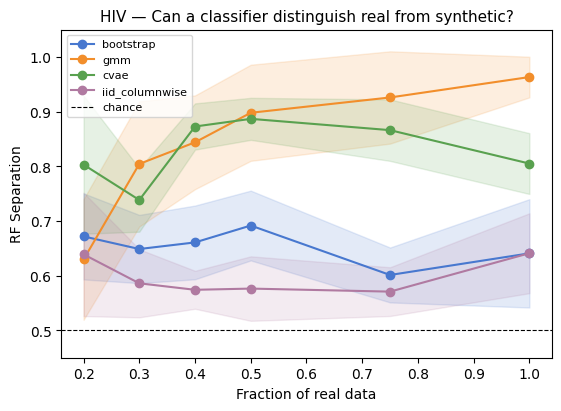

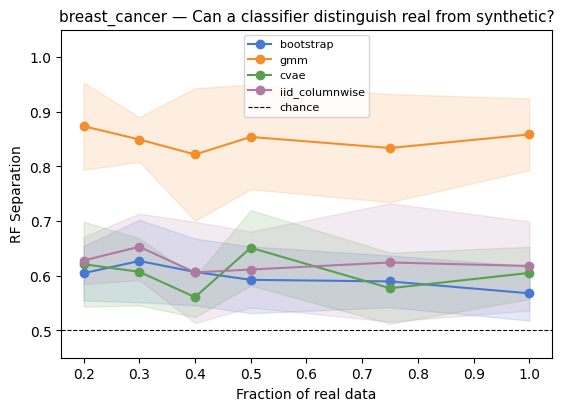

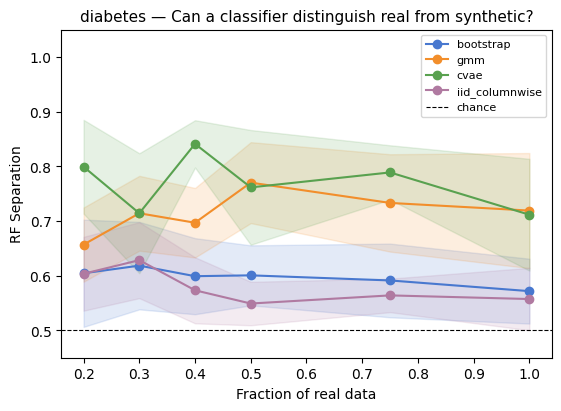

In [7]:
fig1_datasets = ['HIV', 'breast_cancer', 'diabetes']
figs = paper_fig_rf_sep_vs_frac(df_all, datasets=fig1_datasets)

for fig, ds in zip(figs, fig1_datasets):
    save_fig(fig, f'fig1_rf_sep_{ds}')

### Figure 2 — Do real and synthetic overlap in PC space?

PCA projection for HIV at max fraction, all three methods side by side.  
Ellipses show 2-SD contours per class.

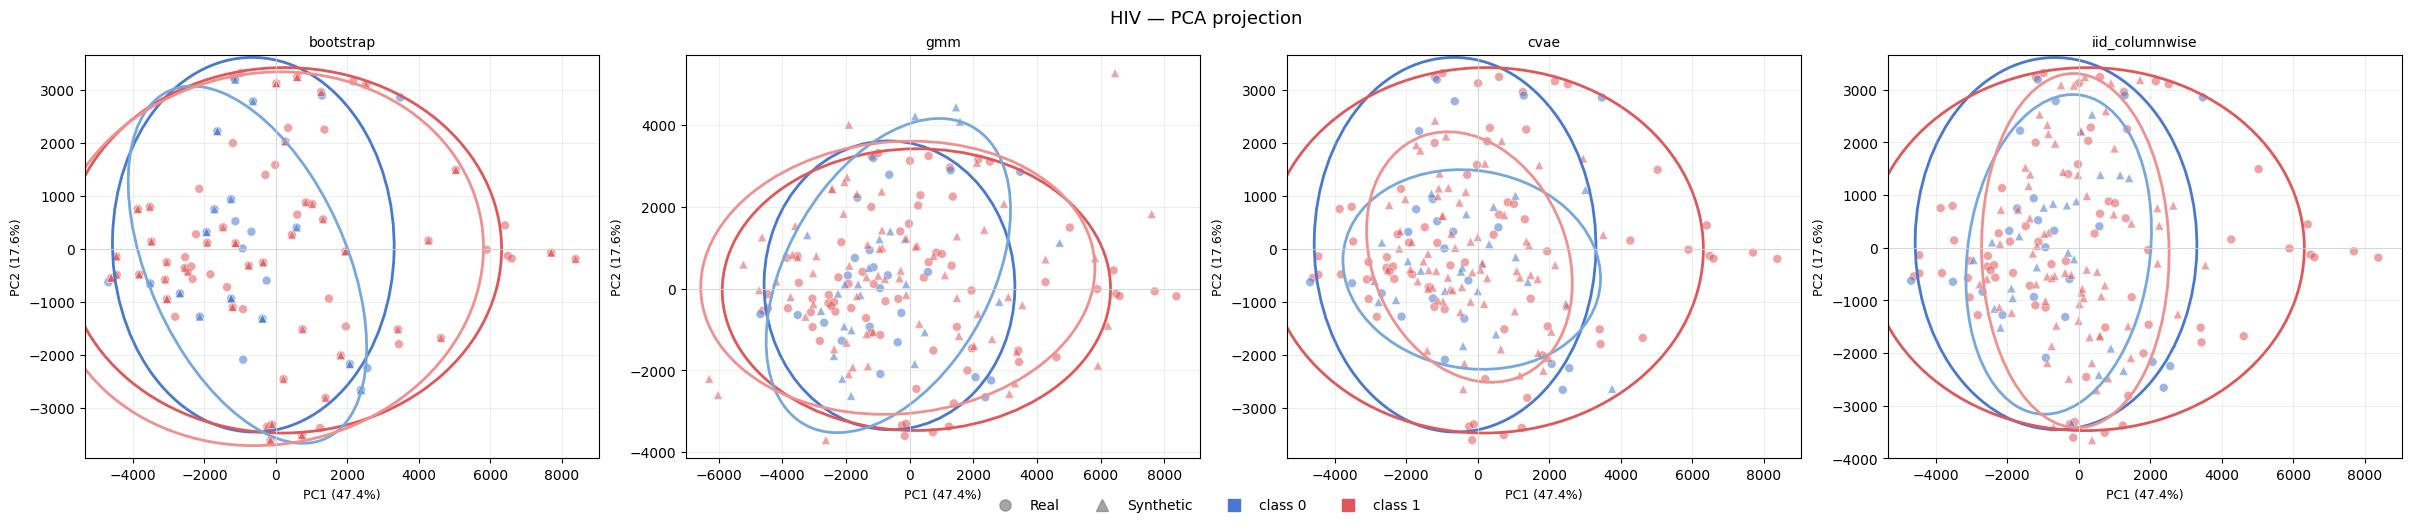

In [8]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, len(METHODS), figsize=(6 * len(METHODS), 5),
                          constrained_layout=True)
for ax, method in zip(axes, METHODS):
    item = get_array('HIV', method)
    if item:
        plot_pca_projection(item['X_real'], item['y_real'],
                            item['X_syn'],  item['y_syn'],
                            ax=ax, title=method)
    else:
        ax.set_visible(False)

# Shared Real / Synthetic legend (markers only — class colors stay in the points)
legend_handles = [
    Line2D([0], [0], marker='o', color='gray', linestyle='',
           markersize=8, alpha=0.7, label='Real'),
    Line2D([0], [0], marker='^', color='gray', linestyle='',
           markersize=8, alpha=0.7, label='Synthetic'),
    Line2D([0], [0], marker='s', color='#4878CF', linestyle='',
           markersize=8, label='class 0'),
    Line2D([0], [0], marker='s', color='#E15759', linestyle='',
           markersize=8, label='class 1'),
]
fig.legend(handles=legend_handles, loc='lower center',
           ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('HIV \u2014 PCA projection', fontsize=13)
save_fig(fig, 'fig2_pca_hiv')

### Figure 3 — Are pairwise correlations preserved?

Correlation triptych (real | synthetic | |diff|) for HIV, bootstrap
(the least distinguishable method).  
If the difference panel is mostly white, the correlation structure is preserved.

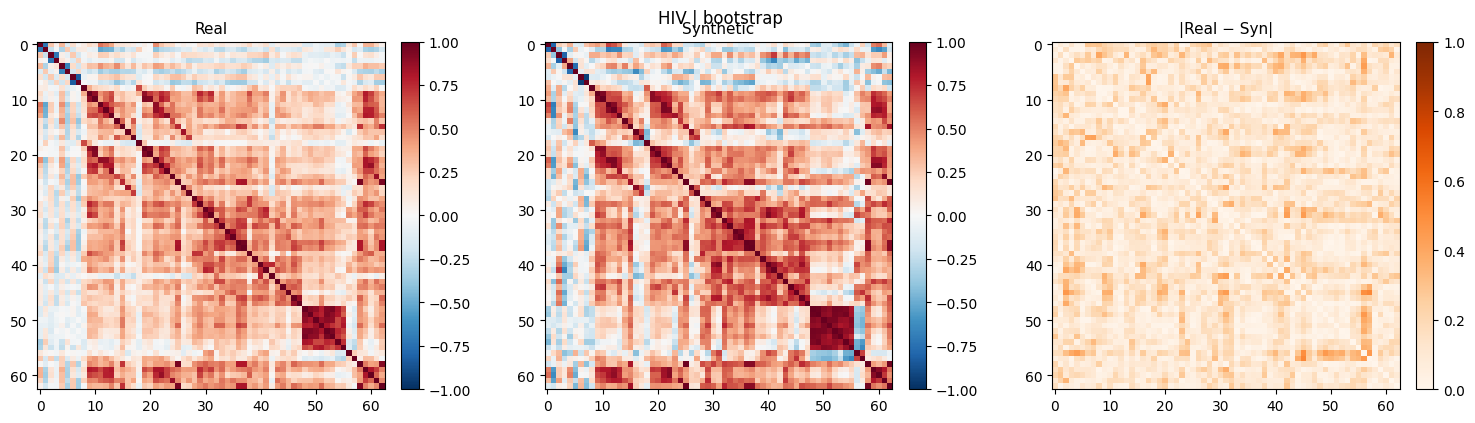

In [18]:
item = get_array('HIV', 'cvae')
if item:
    fig = plot_corr_matrices(
        item['X_real'], item['X_syn'],
        title='HIV | bootstrap',
    )
    save_fig(fig, 'fig3_corr_hiv_bootstrap')

### Figure 4 — Which features are hardest to reproduce?

Grouped KLD bar chart (top 15 features, worst first) for HIV and breast cancer.  
Bars grouped by method — shows whether the same features are hard across all generators.

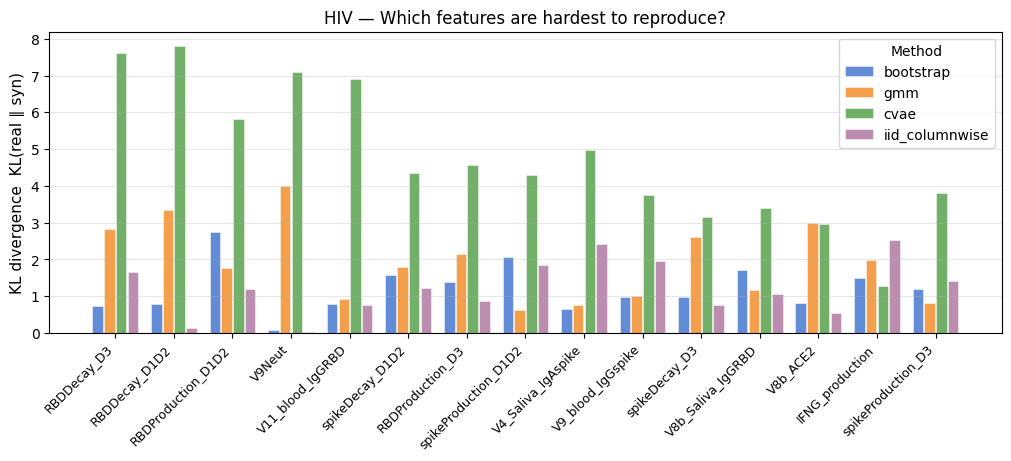

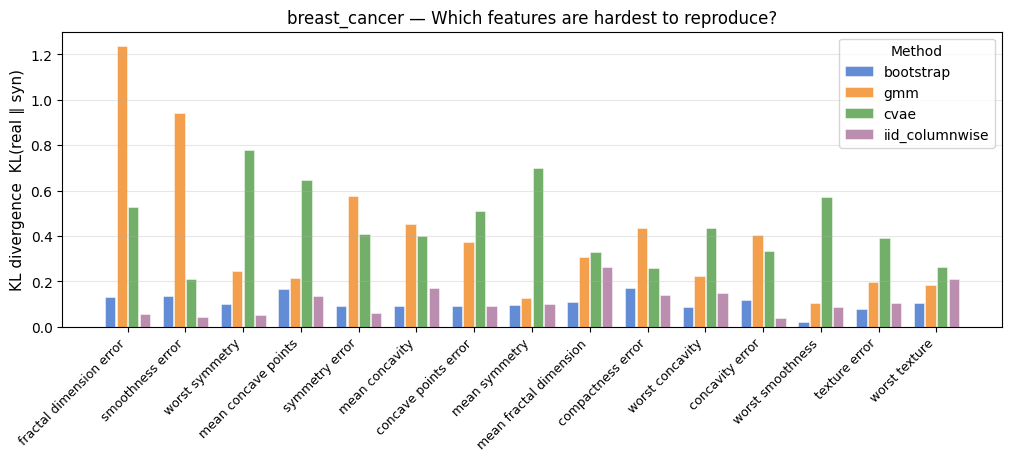

In [10]:
for ds in ['HIV', 'breast_cancer']:
    kld_dict = {}
    for a in all_arrays:
        if a['dataset'] == ds and a['frac'] == FRAC_MAX:
            kld_dict[a['method']] = a['kld_array']

    if len(kld_dict) < 2:
        print(f'{ds}: not enough methods, skipping')
        continue

    fnames = get_feature_names(ds)
    fig = plot_kld_per_feature_by_method(
        kld_dict, feature_names=fnames, top_n=15,
        title=f'{ds} \u2014 Which features are hardest to reproduce?',
    )
    save_fig(fig, f'fig4_kld_{ds}')

### Figure 5 — Do marginal fidelity and classifier separability agree?

Scatter of mean KLD vs RF Separation at each (dataset, method, frac).  
If they agreed, points would form a monotone trend. Disagreement — especially
CVAE having higher KLD but lower RF Sep than GMM — is the core finding.

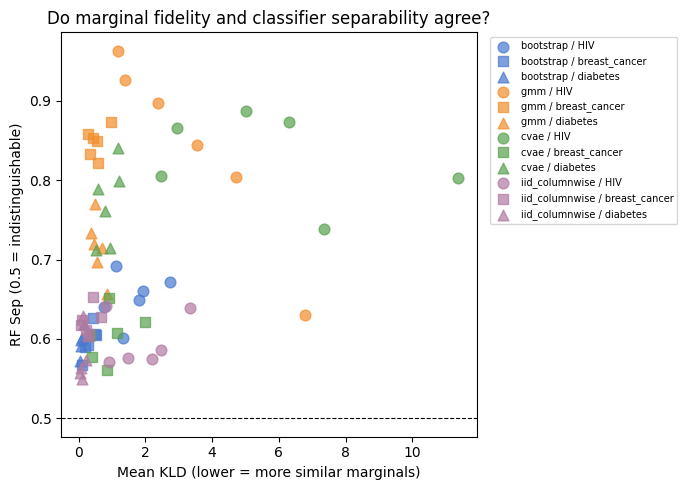

In [11]:
fig = paper_fig_kld_vs_rf_sep(df_all)
save_fig(fig, 'fig5_kld_vs_rf_sep')

### Figure 6 — Is distinguishability concentrated or distributed?

Forward (keep top k) and reverse (drop top k) ablation for HIV.  
If dropping the top features barely helps, the signal is distributed.

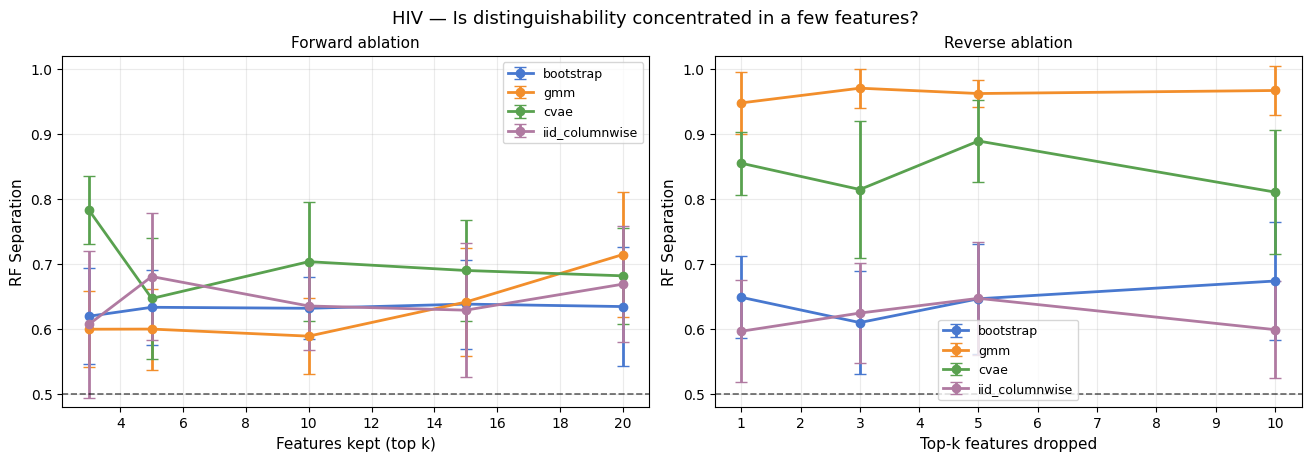

In [12]:
fig = paper_fig_ablation(df_all, 'HIV')
save_fig(fig, 'fig6_ablation_hiv')

### Main results table

Full features, max fraction. One row per dataset × method.

In [13]:
display(make_table_full(df_all, frac=FRAC_MAX))

Table 1 — Full feature results (12 rows)


,Dataset,Method,n₀,n₁,TSTR F1 ↑,TRTR F1 (base),Util Gap ↓,KLD Mean ↓,Corr Diff ↓,Prop Sig ↓,RF Sep (mean ± SD),Disc F1 (mean ± SD)
0,HIV,bootstrap,23,68,0.992701,0.964444,-0.028256,0.756319,0.072019,0.000000,0.641 ± 0.099,0.424 ± 0.112
1,HIV,gmm,23,68,0.985507,0.964444,-0.021063,1.181901,0.079204,0.031746,0.963 ± 0.037,0.895 ± 0.072
2,HIV,cvae,23,68,0.964029,0.964444,0.000416,2.466873,0.121593,0.190476,0.805 ± 0.056,0.757 ± 0.081
3,HIV,iid_columnwise,23,68,0.985075,0.964444,-0.020630,0.813577,0.295962,0.000000,0.641 ± 0.073,0.540 ± 0.058
4,breast_cancer,bootstrap,212,357,0.986034,0.969187,-0.016846,0.087536,0.028775,0.000000,0.568 ± 0.050,0.486 ± 0.082
5,breast_cancer,gmm,212,357,0.954930,0.969187,0.014258,0.275869,0.075630,0.000000,0.858 ± 0.066,0.761 ± 0.077
6,breast_cancer,cvae,212,357,0.973721,0.969187,-0.004533,0.343848,0.064644,0.166667,0.605 ± 0.048,0.526 ± 0.117
7,breast_cancer,iid_columnwise,212,357,0.958678,0.969187,0.010510,0.082996,0.199537,0.000000,0.618 ± 0.081,0.556 ± 0.116
8,diabetes,bootstrap,500,268,0.868217,0.609921,-0.258296,0.050567,0.023314,0.000000,0.572 ± 0.059,0.440 ± 0.109
9,diabetes,gmm,500,268,0.622222,0.609921,-0.012301,0.454899,0.026617,0.125000,0.719 ± 0.105,0.625 ± 0.070


---
## 6. Save results

CSV and pickled arrays for downstream notebooks
(`synthetic_analysis.ipynb`, `paper_story_indistinguishability.ipynb`).

In [14]:
# Save CSV
df_all.to_csv(OUTDIR / 'synthetic_results_all.csv', index=False)
print('Saved:', OUTDIR / 'synthetic_results_all.csv')

# Save raw arrays for downstream plotting notebooks
with open(OUTDIR / 'all_figs.pkl', 'wb') as f:
    pickle.dump(all_arrays, f)
print('Saved:', OUTDIR / 'all_figs.pkl')

# Save all summary tables
save_all_tables(df_all, outdir=OUTDIR)

print(f'\nFigures saved to {FIGDIR.resolve()}:')
for p in sorted(FIGDIR.glob('*.*')):
    print(f'  {p.name}')

Saved: ..\results\synthetic_results_all.csv
Saved: ..\results\all_figs.pkl
Table 1 — Full feature results (72 rows)
Table 2 — Sample size sweep (72 rows)
Table 3 — Forward ablation (48 rows)
Table 4 — Reverse ablation (44 rows)
Table 5 — Drop-one sensitivity (404 rows)
  Saved: ..\results\table1_full.csv
  Saved: ..\results\table2_sample_size.csv
  Saved: ..\results\table3_forward.csv
  Saved: ..\results\table4_reverse.csv
  Saved: ..\results\table5_drop_one.csv

Figures saved to C:\Users\tonyt\Desktop\synthetic-data\results\figures:
  fig1_rf_sep_breast_cancer.pdf
  fig1_rf_sep_breast_cancer.png
  fig1_rf_sep_diabetes.pdf
  fig1_rf_sep_diabetes.png
  fig1_rf_sep_HIV.pdf
  fig1_rf_sep_HIV.png
  fig1_rf_sep_vs_frac.pdf
  fig1_rf_sep_vs_frac.png
  fig2_pca_hiv.pdf
  fig2_pca_hiv.png
  fig3_corr_hiv_bootstrap.pdf
  fig3_corr_hiv_bootstrap.png
  fig4_kld_breast_cancer.pdf
  fig4_kld_breast_cancer.png
  fig4_kld_HIV.pdf
  fig4_kld_HIV.png
  fig5_kld_vs_rf_sep.pdf
  fig5_kld_vs_rf_sep.png
  